In [39]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("C:/Users/Powan/Desktop/Maestria/TFM/edev_models/modelos")

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


# Load dataset

In [2]:
from construir_dataset_maestro import (
        construir_espina_horaria, construir_dataset_diario, dividir_train_val_test,
    )

dataset = construir_dataset_diario()
train_raw, val_raw, test_raw = dividir_train_val_test(dataset)

print(f"train: {len(train_raw)} dias  ({train_raw.index.min()} -> {train_raw.index.max()})")
print(f"val:   {len(val_raw)} dias  ({val_raw.index.min()} -> {val_raw.index.max()})")
print(f"test:  {len(test_raw)} dias  ({test_raw.index.min()} -> {test_raw.index.max()})")

C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_maestro.py:606: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  target_wide = pd.read_sql(
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_maestro.py:236: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\construir_dataset_maestro.py:259: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
C:\Users/Powan/Desktop/Maestria/TFM/edev_models/modelos\co

train: 1822 dias  (2020-01-01 -> 2024-12-31)
val:   364 dias  (2025-01-01 -> 2025-12-31)
test:  224 dias  (2026-01-01 -> 2026-08-13)


In [3]:
HORA_TARGET = "price_h20"  # cambia aqui la hora que quieras predecir

def preparar_xy(df: pd.DataFrame, hora_target: str = HORA_TARGET):
    """Separa target (precio D+1 de una hora concreta) de las features.
    Se descartan TODAS las columnas price_h -- no solo la del target -- porque
    conocer el precio de otras horas del mismo dia D+1 tambien seria fuga de informacion.
    Se aplica por separado a cada split para no filtrar informacion entre ellos."""
    price_cols = [c for c in df.columns if c.startswith("price_h")]
    if hora_target not in price_cols:
        raise ValueError(f"{hora_target!r} no esta en las columnas de precio: {price_cols}")

    y = df[hora_target].rename(hora_target)
    feature_cols = [c for c in df.columns if c not in price_cols]
    return df[feature_cols], y

X_train, y_train = preparar_xy(train_raw)
X_val, y_val = preparar_xy(val_raw)
X_test, y_test = preparar_xy(test_raw)

# Spearman feature selector

In [4]:
def select_features_spearman(
    X: pd.DataFrame,
    y: pd.Series,
    target_threshold: float = 0.10,
    collinearity_threshold: float = 0.90,
    p_value_max: float = 0.05,
    min_overlap: int = 30,
) -> dict:
    """
    Fit this on the TRAIN split only -- selection must not see val/test rows.

    Stage 1: keep features whose Spearman correlation with the target is
    both meaningful (|rho| >= target_threshold) and significant (p < p_value_max).
    Stage 2: among survivors, greedily drop redundant features -- for any pair
    with |pairwise rho| >= collinearity_threshold, keep the one more correlated
    with the target and drop the other.

    Returns:
      selected           -- final feature list, ordered by |rho| with target
      target_corr        -- rho with target for every numeric input feature
      dropped_low_corr    -- cut in stage 1 (weak or non-significant)
      dropped_collinear   -- cut in stage 2, redundant with a stronger feature
    """
    X_num = X.select_dtypes(include=[np.number])

    rho, pval = {}, {}
    for col in X_num.columns:
        mask = X_num[col].notna() & y.notna()
        if mask.sum() < min_overlap:
            rho[col], pval[col] = np.nan, np.nan
            continue
        r, p = spearmanr(X_num.loc[mask, col], y[mask])
        rho[col], pval[col] = r, p

    target_corr = pd.Series(rho)
    pvals = pd.Series(pval)

    survivors = [
        c for c in X_num.columns
        if pd.notna(target_corr[c])
        and abs(target_corr[c]) >= target_threshold
        and pvals[c] < p_value_max
    ]
    dropped_low_corr = [c for c in X_num.columns if c not in survivors]

    corr_matrix = X_num[survivors].corr(method="spearman").abs()
    ordered = target_corr[survivors].abs().sort_values(ascending=False).index.tolist()

    selected, dropped_collinear, excluded = [], [], set()
    for col in ordered:
        if col in excluded:
            continue
        selected.append(col)
        for other in ordered:
            if other == col or other in excluded or other in selected:
                continue
            if corr_matrix.loc[col, other] >= collinearity_threshold:
                excluded.add(other)
                dropped_collinear.append(other)

    return {
        "selected": selected,
        "target_corr": target_corr.sort_values(key=abs, ascending=False),
        "dropped_low_corr": dropped_low_corr,
        "dropped_collinear": dropped_collinear,
    }

In [5]:
result = select_features_spearman(X_train, y_train)
selected = result["selected"]

X_train_sel = X_train[selected]
X_val_sel = X_val[selected]
X_test_sel = X_test[selected]

print(f"target: {HORA_TARGET}")
print(f"{len(selected)} de {X_train.shape[1]} features conservadas")

C:\Users\Powan\AppData\Local\Temp\ipykernel_21096\1382679942.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_num.loc[mask, col], y[mask])
C:\Users\Powan\AppData\Local\Temp\ipykernel_21096\1382679942.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_num.loc[mask, col], y[mask])
C:\Users\Powan\AppData\Local\Temp\ipykernel_21096\1382679942.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_num.loc[mask, col], y[mask])
C:\Users\Powan\AppData\Local\Temp\ipykernel_21096\1382679942.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(X_num.loc[mask, col], y[mask])


target: price_h20
81 de 240 features conservadas


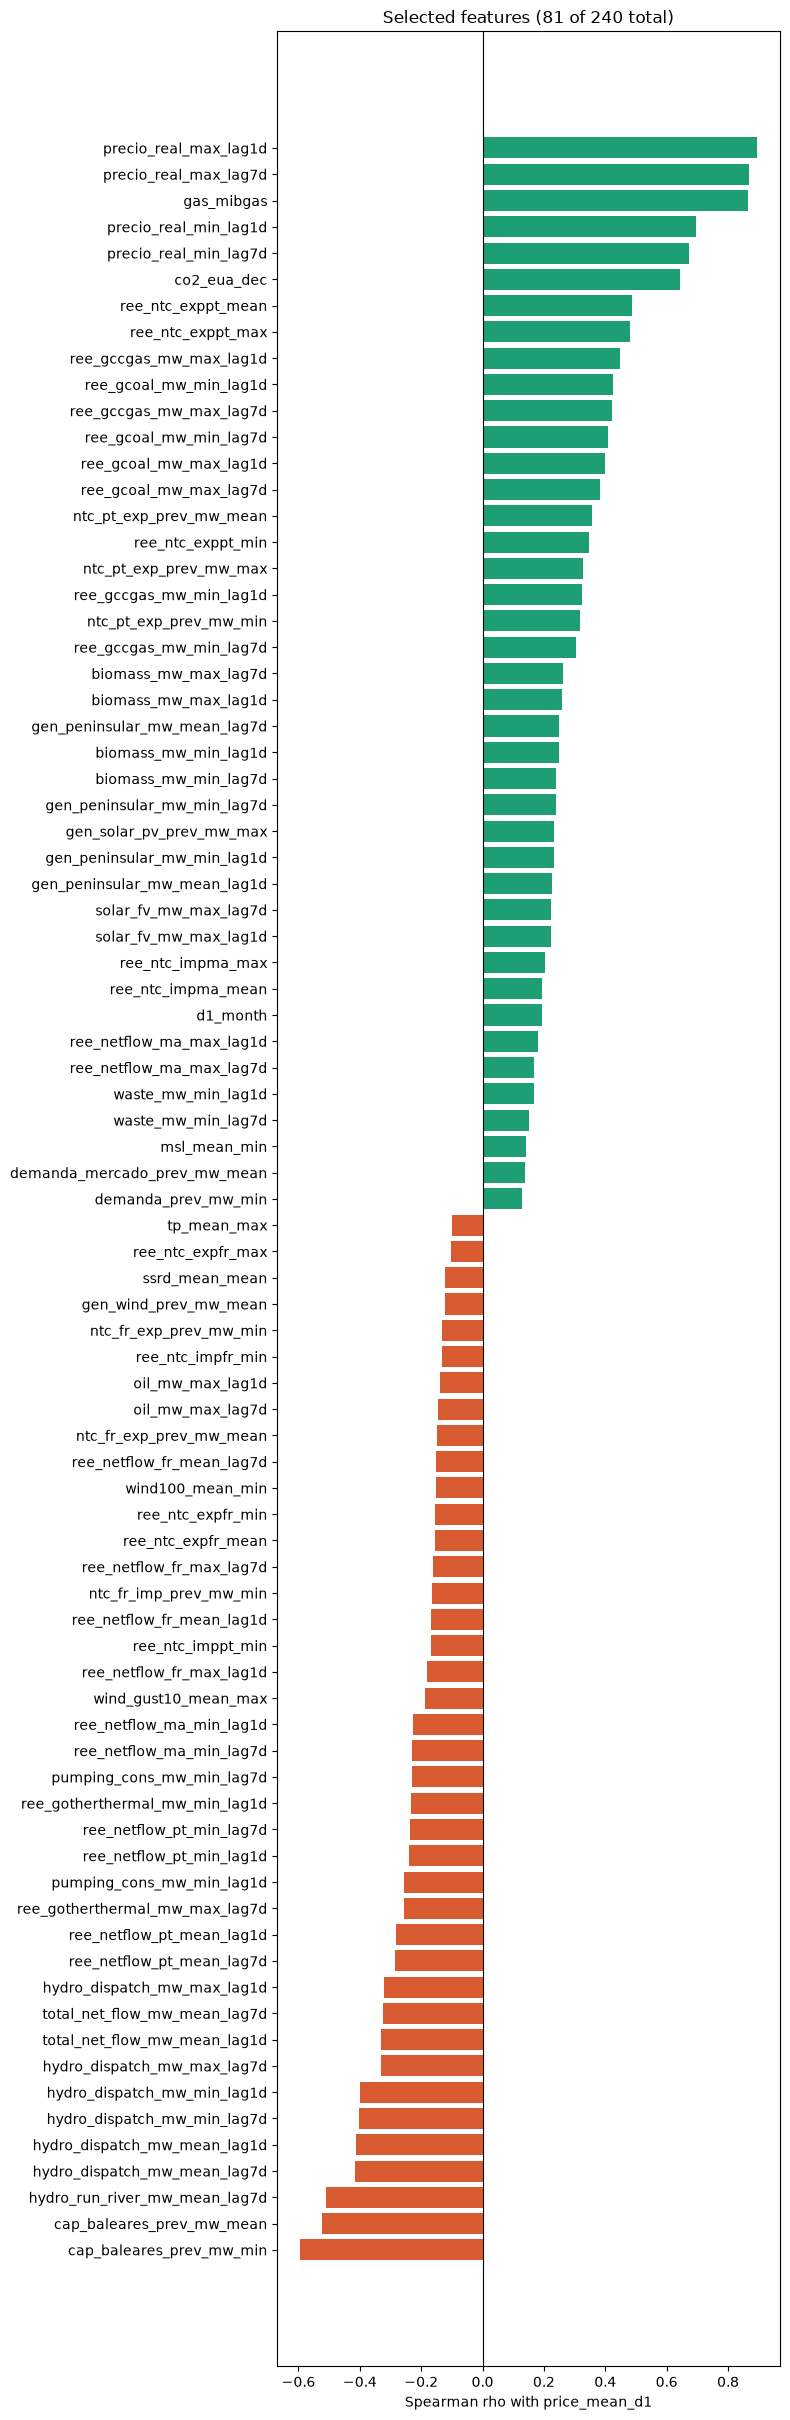

In [6]:

def plot_selected_features(result: dict, top_n: int = None):
    """
    Bar chart of Spearman rho (vs target) for the features `select_features_spearman`
    kept. Sign is preserved -- positive rho (feature rises with price) in one color,
    negative in another.
    """
    selected = result["selected"]
    corr = result["target_corr"][selected]

    if top_n is not None:
        corr = corr.reindex(corr.abs().sort_values(ascending=False).index[:top_n])

    corr = corr.sort_values()  # ascending, so strongest bars end up at the top when plotted

    colors = ["#1D9E75" if v > 0 else "#D85A30" for v in corr]

    fig, ax = plt.subplots(figsize=(8, max(4, len(corr) * 0.3)))
    ax.barh(corr.index, corr.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Spearman rho with price_mean_d1")
    ax.set_title(f"Selected features ({len(selected)} of {len(result['target_corr'])} total)")
    plt.tight_layout()
    plt.show()


plot_selected_features(result)                # all selected features
# plot_selected_features(result, top_n=25)    # just the strongest 25, if the full list is too tall

# Sequential Feature Selector

In [7]:


def select_features_sfs(
    X: pd.DataFrame,
    y: pd.Series,
    n_features_to_select: str | int = "auto",
    direction: str = "forward",
    n_splits: int = 5,
    scoring: str = "neg_mean_absolute_error",
) -> dict:
    """
    Wrapper de seleccion secuencial. Se ajusta SOLO sobre el split de train --
    la seleccion no debe ver filas de val/test (fuga de informacion).

    Usa TimeSeriesSplit en vez de KFold: al ser una serie temporal, la CV nunca
    debe barajar los dias (evita entrenar con "futuro" y validar con "pasado").

    n_features_to_select="auto" deja que sklearn pare cuando dejar de mejorar
    el score deja de compensar (usa el parametro `tol`, por defecto None -> mitad
    de las features de entrada). Puedes fijar un numero concreto en su lugar.

    Devuelve:
      selected  -- lista final de features
      estimator -- el modelo usado para evaluar cada subconjunto (ya no esta fit,
                   es solo la referencia -- hay que reentrenarlo sobre selected)
    """
    estimator = RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    )
    cv = TimeSeriesSplit(n_splits=n_splits)

    sfs = SequentialFeatureSelector(
        estimator,
        n_features_to_select=n_features_to_select,
        direction=direction,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
    )
    sfs.fit(X, y)

    selected = X.columns[sfs.get_support()].tolist()

    return {
        "selected": selected,
        "estimator": estimator,
        "sfs": sfs,
    }

In [8]:
result_sfs = select_features_sfs(X_train_sel, y_train, n_features_to_select="auto", direction="forward")
selected_sfs = result_sfs["selected"]

X_train_sfs = X_train_sel[selected_sfs]
X_val_sfs = X_val_sel[selected_sfs]
X_test_sfs = X_test_sel[selected_sfs]

print(f"{len(selected_sfs)} de {X_train_sel.shape[1]} features conservadas (tras Spearman + SFS)")

40 de 81 features conservadas (tras Spearman + SFS)


# tratamiento de datos

In [9]:
## rellena los huevos menores a 7 posiciones usando interpolate
def rellenar_gaps(df_or_series, limit=7):
    full_idx = pd.date_range(df_or_series.index.min(), df_or_series.index.max(), freq='D')
    out = df_or_series.reindex(full_idx)
    out = out.interpolate(limit=limit)
    out.index.freq = 'D'
    return out

y_train = rellenar_gaps(y_train)
X_train_sfs = rellenar_gaps(X_train_sfs)

y_test = rellenar_gaps(y_test)
X_test_sfs = rellenar_gaps(X_test_sfs)

# tras interpolar, comprobar que no queden NaN (huecos mas largos que `limit` no se rellenan)
print("NaN restantes en X_train_sfs:", X_train_sfs.isna().sum().sum())
print("NaN restantes en y_train:", y_train.isna().sum())

NaN restantes en X_train_sfs: 1327
NaN restantes en y_train: 0


In [10]:
## Revisamos la correlacion de las columnas con muchos missing
missing_pct = X_train_sfs.isna().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0.15]

# cruzar con su fuerza de correlacion con el target
print(pd.DataFrame({
    "missing_pct": high_missing,
    "target_corr": result["target_corr"].reindex(high_missing.index)
}))

                         missing_pct  target_corr
ntc_fr_exp_prev_mw_mean     0.166393    -0.146919
ntc_fr_imp_prev_mw_min      0.166393    -0.166049
ntc_pt_exp_prev_mw_min      0.166393     0.315976
ntc_pt_exp_prev_mw_max      0.166393     0.327124


In [11]:
## Dropeamos las FR por tener una relacion baja

cols_a_dropear = ["ntc_fr_exp_prev_mw_mean", "ntc_fr_imp_prev_mw_min"]

X_train_sfs = X_train_sfs.drop(columns=cols_a_dropear)
X_test_sfs = X_test_sfs.drop(columns=cols_a_dropear)

In [12]:
## Imputamos las de portugal
cols_pt = ["ntc_pt_exp_prev_mw_min", "ntc_pt_exp_prev_mw_max"]
for col in cols_pt:
    X_train_sfs[col] = X_train_sfs[col].bfill()
    X_test_sfs[col] = X_test_sfs[col].bfill()
print("Imputado con bfill (bloque inicial)")

# verificacion final
print("\nNaN restantes en train:", X_train_sfs[cols_pt].isna().sum().to_dict())
print("NaN restantes en test:", X_test_sfs[cols_pt].isna().sum().to_dict())

Imputado con bfill (bloque inicial)

NaN restantes en train: {'ntc_pt_exp_prev_mw_min': 0, 'ntc_pt_exp_prev_mw_max': 0}
NaN restantes en test: {'ntc_pt_exp_prev_mw_min': 0, 'ntc_pt_exp_prev_mw_max': 0}


In [13]:
## interpolate no puede rellenar los iniciales, entonces los rellenamos usando bfill
cols_con_missing = X_train_sfs.columns[X_train_sfs.isna().any()].tolist()

for col in cols_con_missing:
    X_train_sfs[col] = X_train_sfs[col].bfill(limit=7)
    X_test_sfs[col] = X_test_sfs[col].bfill(limit=7)

print("NaN restantes en train:", X_train_sfs.isna().sum().sum())
print("NaN restantes en test:", X_test_sfs.isna().sum().sum())

NaN restantes en train: 0
NaN restantes en test: 0


In [14]:
# 1. Dropear las mismas columnas de Francia
X_val_sfs = X_val_sfs.drop(columns=cols_a_dropear)

# 2. Mismo bfill para el bloque inicial en las columnas que lo necesitaban
for col in cols_con_missing:
    X_val_sfs[col] = X_val_sfs[col].bfill(limit=7)

# 3. Verificar que ahora coincide en columnas y no tiene NaN
print("Columnas iguales a train:", list(X_val_sfs.columns) == list(X_train_sfs.columns))
print("NaN restantes en val:", X_val_sfs.isna().sum().sum())

Columnas iguales a train: True
NaN restantes en val: 0


In [15]:
print("NaN totales en X_train_sfs:", X_train_sfs.isna().sum().sum())
print("NaN totales en X_test_sfs:", X_test_sfs.isna().sum().sum())
print("Inf totales en X_train_sfs:", np.isinf(X_train_sfs.select_dtypes(include=[np.number])).sum().sum())

NaN totales en X_train_sfs: 0
NaN totales en X_test_sfs: 0
Inf totales en X_train_sfs: 0


In [16]:
## igualamos todos los indices
for s in [y_train, y_val, y_test, X_train_sfs, X_val_sfs, X_test_sfs]:
    s.index = pd.to_datetime(s.index)

for nombre, s in [("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
    print(nombre, s.index.dtype)

y_train datetime64[s]
y_val datetime64[s]
y_test datetime64[s]


In [17]:
# Historial completo hasta el borde de test: train + val concatenados, en orden
history_y = pd.concat([y_train, y_val])
history_X = pd.concat([X_train_sfs, X_val_sfs])

print("Ultima fecha del historial:", history_X.index.max())
print("Primera fecha de test:", X_test_sfs.index.min())
print("Diferencia:", X_test_sfs.index.min() - history_X.index.max())  # debe ser 1 dia

Ultima fecha del historial: 2025-12-31 00:00:00
Primera fecha de test: 2026-01-01 00:00:00
Diferencia: 1 days 00:00:00


In [18]:
history_y = history_y.sort_index()
history_X = history_X.sort_index()

history_y = rellenar_gaps(history_y)
history_X = rellenar_gaps(history_X)# ya deja el freq puesto, como viste antes
print("freq history_y:", history_y.index.freq)
print("freq history_X:", history_X.index.freq)
print("NaN tras rellenar_gaps:", history_y.isna().sum(), history_X.isna().sum().sum())
print("Longitud:", len(history_y), len(history_X))

freq history_y: <Day>
freq history_X: <Day>
NaN tras rellenar_gaps: 0 0
Longitud: 2192 2192


In [19]:
# comprobar que el indice sigue siendo diario continuo (sin huecos) antes de forzar el freq
esperado = pd.date_range(history_y.index.min(), history_y.index.max(), freq='D')
print("Indice continuo:", history_y.index.equals(esperado))

history_y.index.freq = 'D'
history_X.index.freq = 'D'

print("freq history_y:", history_y.index.freq)
print("freq history_X:", history_X.index.freq)

Indice continuo: True
freq history_y: <Day>
freq history_X: <Day>


# SARIMA


In [20]:
# 1. Buscar orden propio para el modelo sin exogenas
auto_sin_exog = pm.auto_arima(
    history_y,
    seasonal=True, m=7,
    d=None, D=None,
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True,
)
order_sin_exog = auto_sin_exog.order
seasonal_order_sin_exog = auto_sin_exog.seasonal_order
print(order_sin_exog, seasonal_order_sin_exog)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=4.13 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=20651.874, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=20522.581, Time=0.47 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=20491.354, Time=0.45 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=20649.877, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=20526.009, Time=0.12 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=20470.284, Time=1.07 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=3.38 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=20595.117, Time=0.64 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=20292.179, Time=1.65 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=20310.056, Time=0.70 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=4.89 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=2.70 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=20509.5

In [21]:
# 2. Ajustar sobre el historial (train+val), igual que hiciste con SARIMAX
sarima_fit = SARIMAX(
    history_y,
    order=order_sin_exog,
    seasonal_order=seasonal_order_sin_exog,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

c:\Users\Powan\Desktop\Maestria\TFM\tfm-env\tfm_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
# 3. Walk-forward sobre test, sin exog
predictions = []
current_fit = sarima_fit
for t in range(len(y_test)):
    pred = current_fit.forecast(steps=1)
    predictions.append(pred.iloc[0])
    current_fit = current_fit.append([y_test.iloc[t]], refit=False)

predictions = pd.Series(predictions, index=y_test.index)

In [23]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"SARIMA: MAE: {mae:.2f} €/MWh  RMSE: {rmse:.2f} €/MWh")

SARIMA: MAE: 21.90 €/MWh  RMSE: 29.76 €/MWh


# SARIMAX

In [24]:
# 1. Buscar orden (p,d,q)(P,D,Q,m) con las exogenas incluidas
auto = pm.auto_arima(
    y_train,
    exogenous=X_train_sfs,      # variables seleccionadas por Spearman + SFS
    seasonal=True, m=7,
    d=None, D=None,
    stepwise=True, trace=True,
    error_action='ignore', suppress_warnings=True,
)
order = auto.order
seasonal_order = auto.seasonal_order
print(order, seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=2.91 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17075.685, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=16961.768, Time=0.36 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=16931.908, Time=0.38 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=17073.695, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=16955.181, Time=0.13 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=1.17 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=16925.254, Time=0.83 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=2.78 sec
 ARIMA(0,1,0)(0,0,2)[7] intercept   : AIC=17042.376, Time=0.62 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=16803.529, Time=1.45 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=16808.438, Time=0.71 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=4.53 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=2.37 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=16958.0

In [25]:
# Reajustar SARIMAX sobre el historial completo (train+val), con el order/seasonal_order
# ya encontrado antes con auto_arima sobre train
sarimax_fit = SARIMAX(
    history_y,
    exog=history_X,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

c:\Users\Powan\Desktop\Maestria\TFM\tfm-env\tfm_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [26]:
# Ahora si, el walk-forward sobre test parte de un indice que continua sin huecos
predictions_sarimax = []
current_fit = sarimax_fit
for t in range(len(y_test)):
    exog_t = X_test_sfs.iloc[[t]]
    pred = current_fit.forecast(steps=1, exog=exog_t)
    predictions_sarimax.append(pred.iloc[0])
    current_fit = current_fit.append([y_test.iloc[t]], exog=exog_t, refit=False)

predictions_sarimax = pd.Series(predictions_sarimax, index=y_test.index)

In [ ]:
# 4. Metricas, comparables con el resto de modelos ML y con el SARIMA sin exogenas

mae = mean_absolute_error(y_test, predictions_sarimax)
rmse = np.sqrt(mean_squared_error(y_test, predictions_sarimax))
print(f"SARIMAX + exog: MAE: {mae:.2f} €/MWh  RMSE: {rmse:.2f} €/MWh")

SARIMAX + exog: MAE: 20.60 €/MWh  RMSE: 28.10 €/MWh


# graficos y tablas

In [28]:
naive_pred = y_test.shift(1).bfill()

In [54]:
predictions_dict = {
    "Naive (t-1)": naive_pred,
    "SARIMA (sin exog)": predictions,        
    "SARIMAX (+exog)": predictions_sarimax,
    "Rigde": ridge_pred,
    "Elastic": elasticnet_pred,
    
}   

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calcular_metricas(y_true, predictions_dict, nombre_naive="Naive (t-1)"):
    mae_naive = mean_absolute_error(y_true, predictions_dict[nombre_naive])

    filas = []
    for nombre, pred in predictions_dict.items():
        pred_alineado = pred.reindex(y_true.index)
        mae = mean_absolute_error(y_true, pred_alineado)
        rmse = np.sqrt(mean_squared_error(y_true, pred_alineado))
        filas.append({
            "modelo": nombre,
            "MAE": mae,
            "RMSE": rmse,
            "rMAE": mae / mae_naive,
        })
    return pd.DataFrame(filas).set_index("modelo").sort_values("MAE")

In [30]:


def plot_predicciones_vs_real(y_true, predictions_dict, zoom_dias=None):
    """
    Un panel por modelo, con el precio real superpuesto en cada uno.
    zoom_dias: si se indica (ej. 30), solo muestra los ultimos N dias del test
               -- util cuando el periodo completo hace ilegible el detalle.
    """
    y_plot = y_true
    preds_plot = predictions_dict
    if zoom_dias is not None:
        y_plot = y_true.iloc[-zoom_dias:]
        preds_plot = {name: pred.reindex(y_plot.index) for name, pred in predictions_dict.items()}

    n = len(preds_plot)
    fig, axes = plt.subplots(n, 1, figsize=(11, 3 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, (nombre, pred) in zip(axes, preds_plot.items()):
        ax.plot(y_plot.index, y_plot.values, label="Real", color="#333333", linewidth=1.5)
        ax.plot(pred.index, pred.values, label=nombre, color="#D85A30", linewidth=1.2, alpha=0.85)
        ax.set_title(nombre)
        ax.set_ylabel("€/MWh")
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(alpha=0.3)

    plt.xlabel("Fecha")
    plt.tight_layout()
    plt.show()



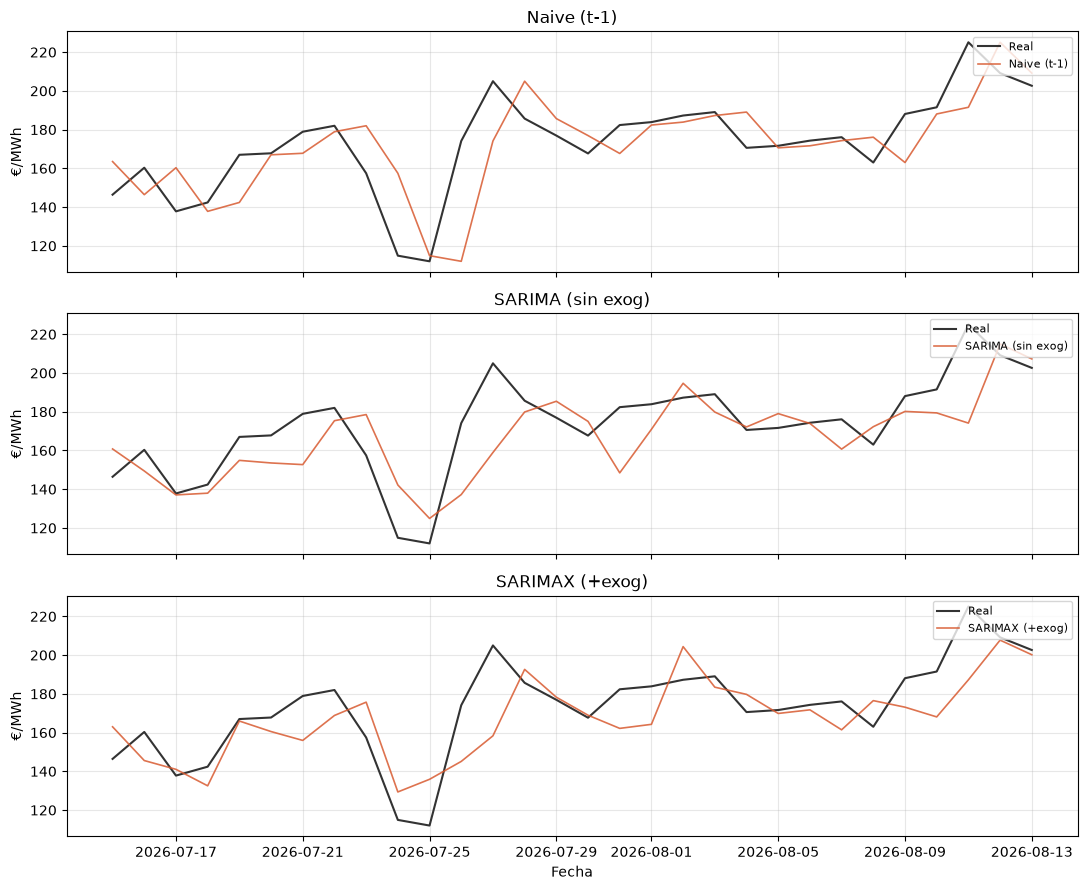

In [31]:
# periodo completo de test
## plot_predicciones_vs_real(y_test, predictions_dict)

# zoom a los ultimos 30 dias, para ver el detalle de picos/valles
plot_predicciones_vs_real(y_test, predictions_dict, zoom_dias=30)

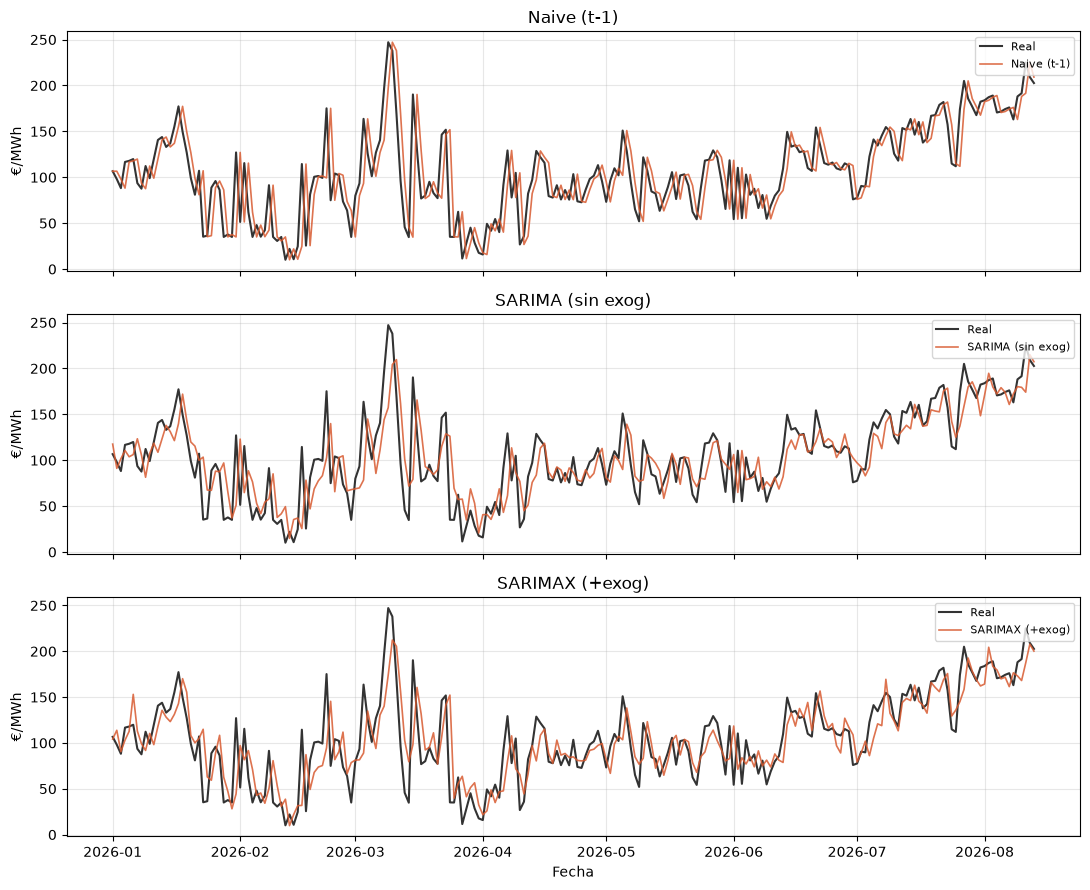

In [32]:
# periodo completo de test
plot_predicciones_vs_real(y_test, predictions_dict)

In [57]:
def tabla_predicciones(y_true, predictions_dict):
    tabla = pd.DataFrame({"Real": y_true})
    for nombre, pred in predictions_dict.items():
        pred_alineado = pred.reindex(y_true.index)
        tabla[nombre] = pred_alineado
        tabla[f"MAE {nombre}"] = (y_true - pred_alineado).abs()  # == MAE de ese dia, n=1
    return tabla.round(2)

tabla = tabla_predicciones(y_test, predictions_dict)
tabla

,Real,Naive (t-1),MAE Naive (t-1),SARIMA (sin exog),MAE SARIMA (sin exog),SARIMAX (+exog),MAE SARIMAX (+exog),Rigde,MAE Rigde,Elastic,MAE Elastic
2026-01-01,106.61,106.61,0.00,117.53,10.92,104.23,2.38,88.92,17.69,90.25,16.36
2026-01-02,98.03,106.61,8.58,91.12,6.91,113.80,15.77,98.89,0.86,98.75,0.72
2026-01-03,88.18,98.03,9.85,101.65,13.47,90.48,2.30,84.82,3.36,85.45,2.73
2026-01-04,116.72,88.18,28.54,110.56,6.16,103.06,13.66,97.14,19.58,97.68,19.04
2026-01-05,117.90,116.72,1.18,103.74,14.16,112.64,5.26,105.95,11.95,106.22,11.68
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-09,188.08,163.01,25.07,180.16,7.92,173.12,14.96,177.71,10.37,176.43,11.65
2026-08-10,191.53,188.08,3.45,179.39,12.14,168.10,23.43,162.57,28.96,160.44,31.09
2026-08-11,225.09,191.53,33.56,174.14,50.95,187.24,37.85,184.70,40.39,183.50,41.59
2026-08-12,209.18,225.09,15.91,214.98,5.80,207.74,1.44,186.58,22.60,185.18,24.00


# regresion lineal


## Rigde

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sfs), index=X_train_sfs.index, columns=X_train_sfs.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_sfs), index=X_val_sfs.index, columns=X_val_sfs.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_sfs), index=X_test_sfs.index, columns=X_test_sfs.columns)

In [40]:
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 200, 500]

resultados_ridge = []
for alpha in alphas:
    modelo = Ridge(alpha=alpha)
    modelo.fit(X_train_scaled, y_train)
    pred_val = modelo.predict(X_val_scaled)
    resultados_ridge.append({"alpha": alpha, "MAE_val": mean_absolute_error(y_val, pred_val)})

resultados_ridge = pd.DataFrame(resultados_ridge).sort_values("MAE_val")
print(resultados_ridge)

best_alpha_ridge = resultados_ridge.iloc[0]["alpha"]
print(f"\nMejor alpha (Ridge): {best_alpha_ridge}")

     alpha    MAE_val
7  100.000  23.155880
6   50.000  23.193513
5   10.000  23.320812
4    5.000  23.351365
3    1.000  23.375614
8  200.000  23.377546
2    0.100  23.380747
1    0.010  23.381308
0    0.001  23.381364
9  500.000  24.334959

Mejor alpha (Ridge): 100.0


In [41]:
history_X_scaled = pd.DataFrame(
    scaler.transform(history_X[X_train_sfs.columns]),
    index=history_X.index, columns=X_train_sfs.columns
)

# Ridge final
ridge_final = Ridge(alpha=best_alpha_ridge)
ridge_final.fit(history_X_scaled, history_y)
ridge_pred = pd.Series(ridge_final.predict(X_test_scaled), index=y_test.index)

In [50]:
metricas = calcular_metricas(y_test, predictions_dict)
print(metricas)

                         MAE       RMSE      rMAE
modelo                                           
SARIMAX (+exog)    20.600112  28.104434  0.871948
SARIMA (sin exog)  21.899368  29.764383  0.926943
Naive (t-1)        23.625378  33.371000  1.000000
Rigde              25.909199  35.633992  1.096668


## ElasticNet

In [51]:
from sklearn.linear_model import ElasticNet
import itertools

alphas_en = [0.001, 0.01, 0.1, 1, 5, 10]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]  # 1.0 = Lasso puro

resultados_en = []
for alpha, l1_ratio in itertools.product(alphas_en, l1_ratios):
    modelo = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    modelo.fit(X_train_scaled, y_train)
    pred_val = modelo.predict(X_val_scaled)
    resultados_en.append({
        "alpha": alpha, "l1_ratio": l1_ratio,
        "MAE_val": mean_absolute_error(y_val, pred_val)
    })

resultados_en = pd.DataFrame(resultados_en).sort_values("MAE_val")
print(resultados_en.head(10))

best_alpha_en = resultados_en.iloc[0]["alpha"]
best_l1_ratio_en = resultados_en.iloc[0]["l1_ratio"]
print(f"\nMejor combinacion (ElasticNet): alpha={best_alpha_en}, l1_ratio={best_l1_ratio_en}")

    alpha  l1_ratio    MAE_val
14  0.100       0.5  23.188809
13  0.100       0.3  23.194434
12  0.100       0.1  23.265058
15  0.100       0.7  23.270875
6   0.010       0.1  23.293495
7   0.010       0.3  23.314350
8   0.010       0.5  23.337053
9   0.010       0.7  23.364196
0   0.001       0.1  23.372376
1   0.001       0.3  23.375140

Mejor combinacion (ElasticNet): alpha=0.1, l1_ratio=0.5


In [52]:
# ElasticNet final
en_final = ElasticNet(alpha=best_alpha_en, l1_ratio=best_l1_ratio_en, max_iter=10000)
en_final.fit(history_X_scaled, history_y)
elasticnet_pred = pd.Series(en_final.predict(X_test_scaled), index=y_test.index)

In [56]:
metricas = calcular_metricas(y_test, predictions_dict)
print(metricas)

                         MAE       RMSE      rMAE
modelo                                           
SARIMAX (+exog)    20.600112  28.104434  0.871948
SARIMA (sin exog)  21.899368  29.764383  0.926943
Naive (t-1)        23.625378  33.371000  1.000000
Elastic            25.853739  35.613546  1.094321
Rigde              25.909199  35.633992  1.096668
